## Logistic Regression

### Import Dependencies

In [13]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import mean_absolute_error,mean_squared_error 

In [14]:
# Import data
players = pd.read_csv("2.3.1.training_data.csv")

# Pick one or more input features
feature_cols = ["performance"]  # can be ["performance"] or many

# Normalize feature input to list
if isinstance(feature_cols, str):
    feature_cols = [feature_cols]

# Keep only valid columns
feature_cols = [c for c in feature_cols if c in players.columns]
if len(feature_cols) == 0:
    raise ValueError("No valid feature columns found in dataset.")

# Collect rank one-hot columns (handles duplicate names with trailing spaces)
rank_cols = [c for c in players.columns if c.startswith("rank_")]
rank_groups = {}
for c in rank_cols:
    rank_groups.setdefault(c.strip(), []).append(c)

rank_flags = pd.DataFrame(
    {
        rank_name: players[cols].astype(bool).any(axis=1)
        for rank_name, cols in rank_groups.items()
    }
)

# Keep rows that have at least one rank label
valid_rows = rank_flags.any(axis=1)

# Features (X) and target (y)
X_ranks = players.loc[
    valid_rows, feature_cols
].copy()  # always DataFrame, even with 1 feature
y_ranks = (
    rank_flags.loc[valid_rows].idxmax(axis=1).str.replace("rank_", "", regex=False)
)

# Drop rows with missing feature values
mask = X_ranks.notna().all(axis=1)
X_ranks = X_ranks.loc[mask]
y_ranks = y_ranks.loc[mask]

print("Selected features:", feature_cols)
print("X shape:", X_ranks.shape)
print("y shape:", y_ranks.shape)
print("Classes:", sorted(y_ranks.unique()))
X_ranks.head()

Selected features: ['performance']
X shape: (286, 1)
y shape: (286,)
Classes: ['Ascendant', 'Bronze', 'Diamond', 'Gold', 'Immortal', 'Iron', 'Platinum', 'Radiant', 'Silver', 'Unranked']


,performance
0,0.520810
1,0.672919
2,0.404802
3,0.311697
4,0.469655


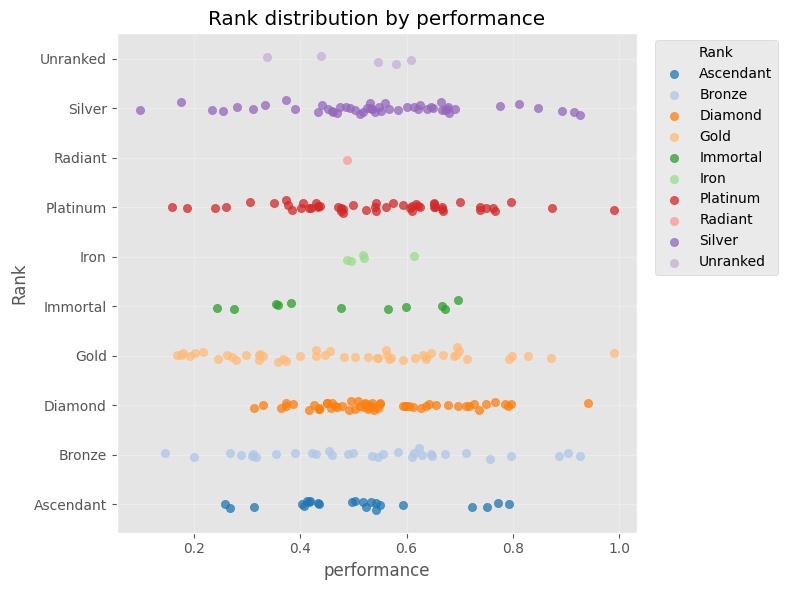

In [15]:
# Matplotlib-only plot: supports 1 or many features
classes = sorted(y_ranks.unique())
colors = plt.cm.tab20.colors

if len(feature_cols) == 1:
    # 1D class plot (feature vs class bands)
    feature_x = feature_cols[0]
    rng = np.random.default_rng(42)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i, rank_name in enumerate(classes):
        idx = y_ranks == rank_name
        x_vals = X_ranks.loc[idx, feature_x].to_numpy()
        y_jitter = i + rng.normal(
            0, 0.06, size=x_vals.shape[0]
        )  # slight jitter for visibility
        ax.scatter(
            x_vals,
            y_jitter,
            s=35,
            alpha=0.75,
            color=colors[i % len(colors)],
            label=rank_name,
        )

    ax.set_title(f"Rank distribution by {feature_x}")
    ax.set_xlabel(feature_x)
    ax.set_ylabel("Rank")
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes)
    ax.grid(True, alpha=0.3)

else:
    # 2D class plot (uses first two selected features)
    feature_x = feature_cols[0]
    feature_y = feature_cols[1]

    fig, ax = plt.subplots(figsize=(8, 6))
    for i, rank_name in enumerate(classes):
        idx = y_ranks == rank_name
        ax.scatter(
            X_ranks.loc[idx, feature_x],
            X_ranks.loc[idx, feature_y],
            s=35,
            alpha=0.75,
            color=colors[i % len(colors)],
            label=rank_name,
        )

    ax.set_title(f"Rank distribution: {feature_x} vs {feature_y}")
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.grid(True, alpha=0.3)

ax.legend(title="Rank", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [16]:
val_regression = LogisticRegression()

In [17]:
val_regression.fit(X_ranks, y_ranks)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

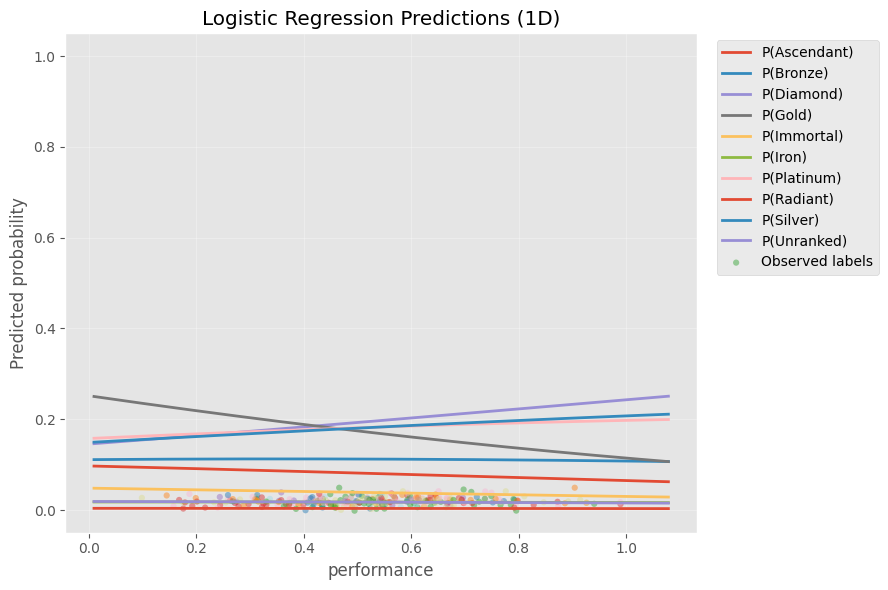

In [18]:
# Plot logistic regression predictions (works with 1, 2, or many features)
classes = np.array(sorted(y_ranks.unique()))
class_to_int = {c: i for i, c in enumerate(classes)}
y_int = np.array([class_to_int[c] for c in y_ranks])

if len(feature_cols) == 1:
    # 1D: probability curves + observed points
    fx = feature_cols[0]
    x = X_ranks[fx].to_numpy()

    pad = (x.max() - x.min()) * 0.1 if x.max() > x.min() else 1.0
    x_grid = np.linspace(x.min() - pad, x.max() + pad, 400)

    grid_df = pd.DataFrame({fx: x_grid})
    proba = val_regression.predict_proba(grid_df)

    fig, ax = plt.subplots(figsize=(9, 6))
    for i, cls in enumerate(val_regression.classes_):
        ax.plot(x_grid, proba[:, i], linewidth=2, label=f"P({cls})")

    # observed labels (jittered near 0)
    rng = np.random.default_rng(42)
    ax.scatter(
        x,
        0.02 + rng.normal(0, 0.01, size=len(x)),
        c=y_int,
        cmap="tab20",
        s=20,
        alpha=0.45,
        edgecolor="none",
        label="Observed labels",
    )

    ax.set_title("Logistic Regression Predictions (1D)")
    ax.set_xlabel(fx)
    ax.set_ylabel("Predicted probability")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

else:
    # 2D view: use first two features; fix extra features at median
    fx, fy = feature_cols[0], feature_cols[1]
    x0 = X_ranks[fx].to_numpy()
    x1 = X_ranks[fy].to_numpy()

    pad0 = (x0.max() - x0.min()) * 0.1 if x0.max() > x0.min() else 1.0
    pad1 = (x1.max() - x1.min()) * 0.1 if x1.max() > x1.min() else 1.0
    xx, yy = np.meshgrid(
        np.linspace(x0.min() - pad0, x0.max() + pad0, 250),
        np.linspace(x1.min() - pad1, x1.max() + pad1, 250),
    )

    grid_df = pd.DataFrame(np.zeros((xx.size, len(feature_cols))), columns=feature_cols)

    # Set fixed values for all features (medians), then override first two with mesh values
    for col in feature_cols:
        grid_df[col] = X_ranks[col].median()
    grid_df[fx] = xx.ravel()
    grid_df[fy] = yy.ravel()

    pred_grid = val_regression.predict(grid_df)
    pred_int = np.array([class_to_int[c] for c in pred_grid]).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.contourf(
        xx,
        yy,
        pred_int,
        levels=np.arange(len(classes) + 1) - 0.5,
        alpha=0.25,
        cmap="tab20",
    )
    scatter = ax.scatter(
        x0, x1, c=y_int, cmap="tab20", s=35, edgecolor="k", linewidth=0.3
    )

    ax.set_title("Logistic Regression Predictions")
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.grid(True, alpha=0.3)

    handles, _ = scatter.legend_elements()
    ax.legend(
        handles, classes, title="Rank", bbox_to_anchor=(1.02, 1), loc="upper left"
    )
    plt.tight_layout()
    plt.show()